<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch07_additional_algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7: Additional Libraries and Algorithms for Outlier Detection

*Outlier Detection in Python* -- Brett Kennedy (Manning, 2024)

---

This chapter expands the toolkit beyond scikit-learn and PyOD, covering additional libraries (alibi-detect, PyCaret) and -- more importantly -- a collection of algorithms that fill critical gaps: **categorical data support**, **interpretability**, and **alternative perspectives** on what constitutes an outlier.

We implement several algorithms from scratch, demonstrating that coding outlier detectors is often surprisingly straightforward. This is valuable not just for using these specific algorithms but for building the confidence to create custom detectors tailored to your project's needs.

**Algorithms covered:**
- **LoOP** (Local Outlier Probability): LOF variant with probabilistic scores
- **LDOF** (Local Distance-Based Outlier Factor): simpler LOF variant
- **EIF** (Extended Isolation Forest): IF with non-axis-aligned splits
- **ODIN** (Outlier Detection Using In-degree Number): reverse KNN
- **Clustering-based**: Mahalanobis per cluster, KDE per cluster, kmodes for categorical
- **Entropy**: categorical outlier detection via information theory
- **Association Rules**: interpretable categorical outlier detection
- **Convex Hull**: geometric peeling method
- **Distance Metric Learning**: RandomForest-based similarity
- **NearestSample**: fast, sample-based distance method

## Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.neighbors import BallTree, KernelDensity
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.covariance import MinCovDet
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print("Environment ready.")

Environment ready.


We rely on scikit-learn and SciPy as the foundation. Several algorithms in this chapter are implemented from scratch, using `BallTree` for nearest-neighbor queries and `ConvexHull` from SciPy for geometric operations.

## 7.1 Synthetic Test Datasets

We use two simple 2D datasets throughout this chapter to test each algorithm. The first is a single Gaussian cluster (the simplest case). The second has four clusters of different sizes, densities, and shapes, plus three global outliers -- a more challenging scenario.

Figure 7.1: Two test datasets used throughout this chapter.


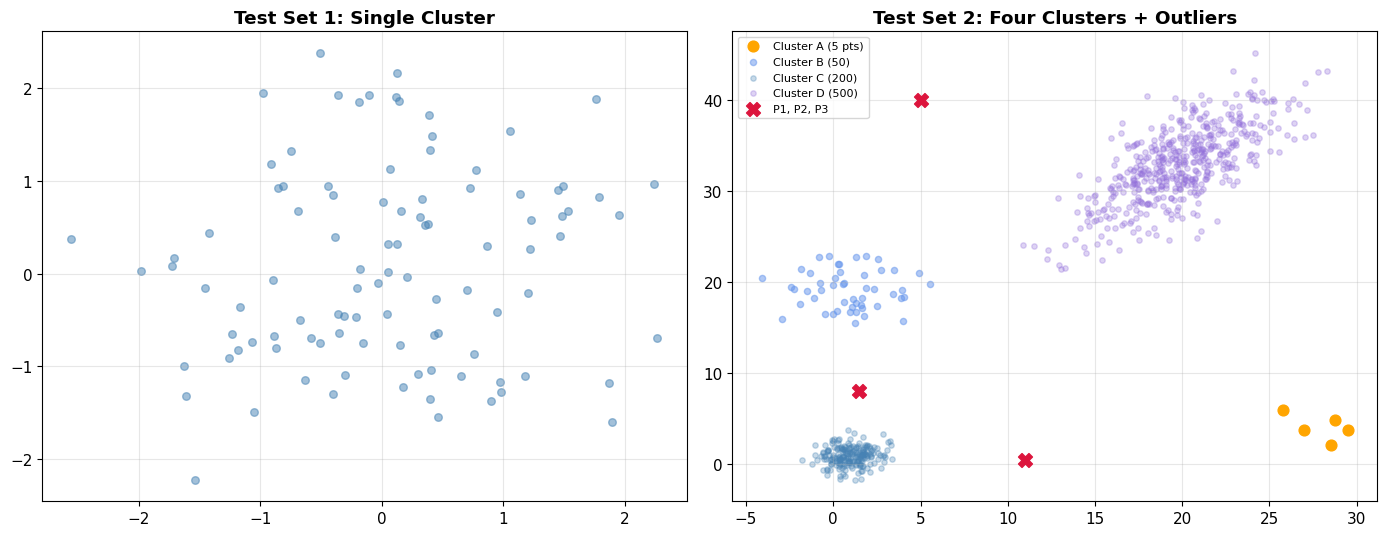

In [2]:
# Listings 7.1 and 7.2: Create two test datasets
def create_simple_testdata():
    np.random.seed(0)
    a_data = np.random.normal(size=100)
    b_data = np.random.normal(size=100)
    return pd.DataFrame({"A": a_data, "B": b_data})

def create_four_clusters_test_data():
    np.random.seed(0)
    # Cluster A: very small (5 points) -- effectively outliers
    df0 = pd.DataFrame({"A": np.random.normal(25.0, 2.0, 5), "B": np.random.normal(4.0, 2.0, 5)})
    # Cluster B: medium (50 points)
    df1 = pd.DataFrame({"A": np.random.normal(1.0, 2.0, 50), "B": np.random.normal(19.0, 2.0, 50)})
    # Cluster C: large, dense (200 points)
    df2 = pd.DataFrame({"A": np.random.normal(1.0, 1.0, 200), "B": np.random.normal(1.0, 1.0, 200)})
    # Cluster D: largest, correlated (500 points)
    a = np.random.normal(20.0, 3.0, 500)
    df3 = pd.DataFrame({"A": a, "B": np.random.normal(13.0, 3.0, 500) + a})
    # Three global outliers
    df4 = pd.DataFrame([[5.0, 40], [1.5, 8.0], [11.0, 0.5]], columns=['A', 'B'])
    df = pd.concat([df0, df1, df2, df3, df4], ignore_index=True)
    return df

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

df_simple = create_simple_testdata()
ax = axes[0]
ax.scatter(df_simple['A'], df_simple['B'], alpha=0.5, s=30, c='steelblue')
ax.set_title('Test Set 1: Single Cluster', fontweight='bold')

df_four = create_four_clusters_test_data()
ax = axes[1]
ax.scatter(df_four.iloc[:5]['A'], df_four.iloc[:5]['B'], s=60, c='orange', label='Cluster A (5 pts)')
ax.scatter(df_four.iloc[5:55]['A'], df_four.iloc[5:55]['B'], alpha=0.5, s=20, c='cornflowerblue', label='Cluster B (50)')
ax.scatter(df_four.iloc[55:255]['A'], df_four.iloc[55:255]['B'], alpha=0.3, s=15, c='steelblue', label='Cluster C (200)')
ax.scatter(df_four.iloc[255:755]['A'], df_four.iloc[255:755]['B'], alpha=0.3, s=15, c='mediumpurple', label='Cluster D (500)')
ax.scatter(df_four.iloc[755:]['A'], df_four.iloc[755:]['B'], s=100, c='crimson', marker='X', zorder=5, label='P1, P2, P3')
ax.set_title('Test Set 2: Four Clusters + Outliers', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
print("Figure 7.1: Two test datasets used throughout this chapter.")

Test Set 2 contains several types of outliers: **Cluster A** ($5$ points at top-right) is a tiny cluster that most algorithms should flag. **P1, P2, P3** are global outliers far from all clusters. Points on the fringes of Clusters B, C, and D are local outliers. Different algorithms will emphasize different subsets of these.

In [3]:
def plot_detector_results(name, score_col='Score'):
    """Run a detector on both test datasets and plot results."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, df, title in [(axes[0], df_res1, 'Single Cluster'), (axes[1], df_res2, 'Four Clusters')]:
        sc = ax.scatter(df['A'], df['B'], c=df[score_col],
                        s=5 + 60*(df[score_col]-df[score_col].min())/(df[score_col].max()-df[score_col].min()+1e-10),
                        cmap='YlOrRd', alpha=0.6)
        ax.set_title(f'{name}: {title}', fontweight='bold')
    plt.tight_layout()
    return fig

print("Helper function defined.")

Helper function defined.


We define a helper function to visualize detector results on both test datasets simultaneously, using color and size to encode outlier scores.

## 7.2 Local Distance-Based Outlier Factor (LDOF)

**LDOF** is a variation of LOF that compares each point's distance to its $k$ nearest neighbors against the distances *between* those neighbors (rather than comparing to the neighbors' distances to *their* neighbors, as LOF does). This makes LDOF more strictly local -- it works with a smaller, more focused set of records.

$$\text{LDOF}(\mathbf{x}) = \frac{\overline{d}(\mathbf{x}, N_k)}{\overline{d}_{\text{inner}}(N_k)}$$

where $\overline{d}(\mathbf{x}, N_k)$ is the average distance from $\mathbf{x}$ to its $k$ neighbors, and $\overline{d}_{\text{inner}}(N_k)$ is the average pairwise distance among those neighbors.

Figure 7.3: LDOF results on both test datasets.


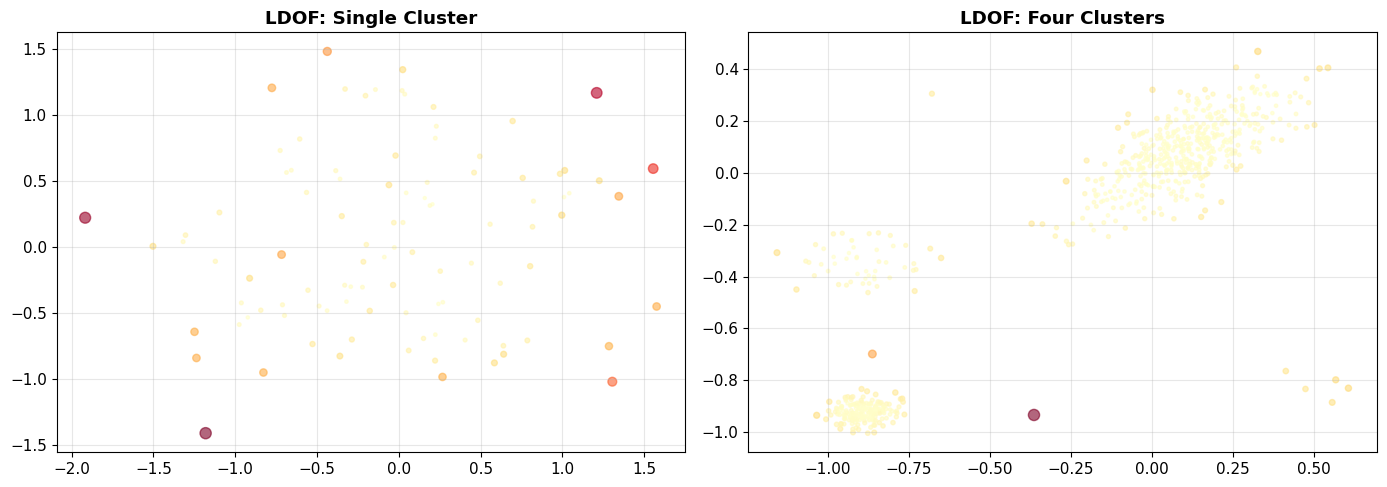

In [4]:
# Listing 7.5: LDOF implementation
class LDOFOutlierDetector:
    def __init__(self):
        pass
    def fit_predict(self, df, k):
        balltree = BallTree(df)
        dist, ind = balltree.query(df, k=k)
        knn_distances = np.array([x.mean() for x in dist])
        inner_distances = []
        for i in range(len(df)):
            neighbors = df.iloc[ind[i]]
            local_tree = BallTree(neighbors)
            local_dist, _ = local_tree.query(neighbors, k=min(k, len(neighbors)))
            inner_distances.append(local_dist.mean())
        inner_distances = np.array(inner_distances)
        inner_distances[inner_distances == 0] = 1e-10
        return knn_distances / inner_distances

# Run on both datasets
df_res1 = create_simple_testdata()
df_res1 = pd.DataFrame(RobustScaler().fit_transform(df_res1), columns=df_res1.columns)
clf = LDOFOutlierDetector()
df_res1['Score'] = clf.fit_predict(df_res1, k=10)

df_res2 = create_four_clusters_test_data()
df_res2 = pd.DataFrame(RobustScaler().fit_transform(df_res2), columns=df_res2.columns)
df_res2['Score'] = clf.fit_predict(df_res2, k=20)

plot_detector_results('LDOF')
print("Figure 7.3: LDOF results on both test datasets.")

LDOF performs well on both datasets. With the single cluster, points on the margin score highest. With four clusters, the small cluster and global outliers receive the highest scores -- the ratio-based scoring normalizes across regions of different density, similar to LOF's local comparison but using a simpler formulation.

The implementation is compact: `BallTree` handles the nearest-neighbor queries, and the core logic is just the ratio of two average distances. This is typical of many outlier detection algorithms -- the ideas are elegant and the implementations surprisingly short.

## 7.3 ODIN: Outlier Detection Using In-Degree Number

**ODIN** inverts the KNN perspective. Instead of asking "how far are my nearest neighbors?", ODIN asks **"how many other points consider me a nearest neighbor?"** This is the **reverse KNN** or **in-degree** concept.

Inliers, sitting in dense regions, are nearest neighbors of many other points (high in-degree). Outliers, sitting in sparse regions, are nearest neighbors of few or no other points (low in-degree). This provides a complementary view to standard KNN.

Figure 7.7: ODIN results. Points on cluster margins score high (few points consider them neighbors).


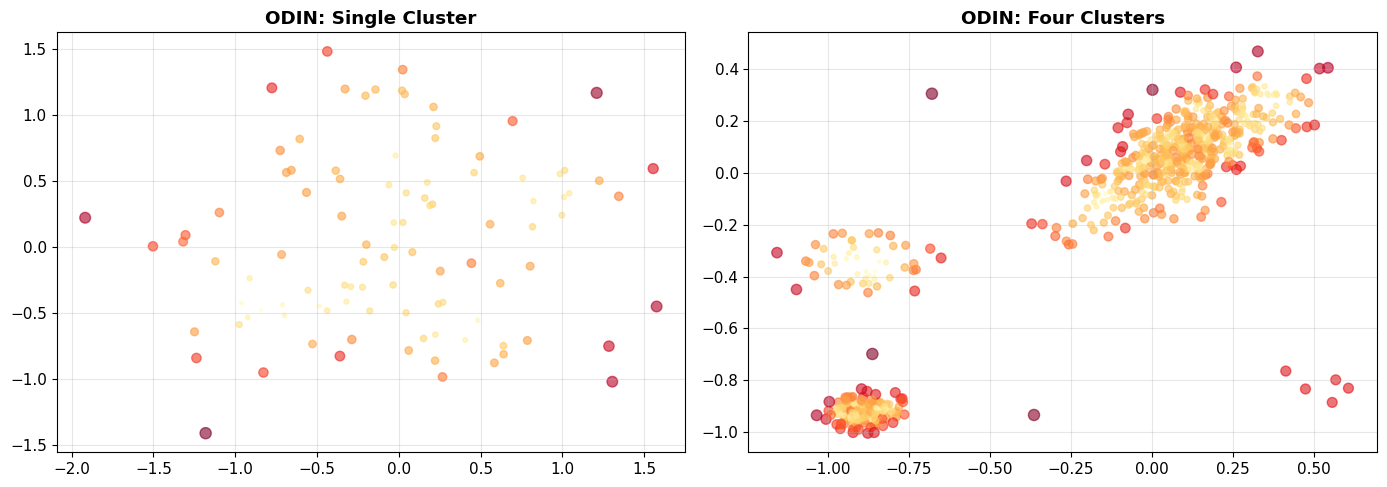

In [5]:
# Listing 7.7: ODIN implementation
class ODINOutlierDetector:
    def __init__(self):
        pass
    def fit_predict(self, df_in, k):
        df = df_in.copy()
        num_rows = len(df)
        b = BallTree(df)
        dist, ind = b.query(df, k=k)
        df['ODIN Score'] = np.zeros(num_rows)
        for current_k in range(1, k):
            current_ind = ind[:, current_k]
            c = Counter(current_ind)
            counts = np.array([c.get(x, 0) for x in range(num_rows)])
            df['ODIN Score'] += (k - current_k) * counts
        min_s = df['ODIN Score'].min(); max_s = df['ODIN Score'].max()
        return (max_s - df['ODIN Score']) / (max_s - min_s + 1e-10)

df_res1 = create_simple_testdata()
df_res1 = pd.DataFrame(RobustScaler().fit_transform(df_res1), columns=df_res1.columns)
df_res1['Score'] = ODINOutlierDetector().fit_predict(df_res1, k=15)

df_res2 = create_four_clusters_test_data()
df_res2 = pd.DataFrame(RobustScaler().fit_transform(df_res2), columns=df_res2.columns)
df_res2['Score'] = ODINOutlierDetector().fit_predict(df_res2, k=20)

plot_detector_results('ODIN')
print("Figure 7.7: ODIN results. Points on cluster margins score high (few points consider them neighbors).")

ODIN provides a distinct perspective from standard KNN. The weighted in-degree score (closer neighbors weighted higher) produces smooth gradients from cluster interiors to edges. Margin points score high because, while they may have a few nearby neighbors, relatively few *other* points list them as nearest neighbors.

The implementation counts, for each $k$-value, how many times each point appears as someone else's $k$-th nearest neighbor, weighting closer matches higher. The final score is reversed (low in-degree = high outlier score) and normalized to $[0, 1]$.

## 7.4 Clustering-Based Outlier Detection

Running **global outlier tests on each cluster separately** is one of the most powerful and underused strategies in outlier detection. By comparing each point only to its cluster, we get meaningful local scores regardless of cross-cluster density differences.

### 7.4.1 Mahalanobis Distance per Cluster

For each cluster, compute the Mahalanobis distance from each point to its cluster center and normalize by the cluster's average Mahalanobis distance. This creates a ratio that is comparable across clusters.

Figure 7.8: Cluster-based Mahalanobis distance results.


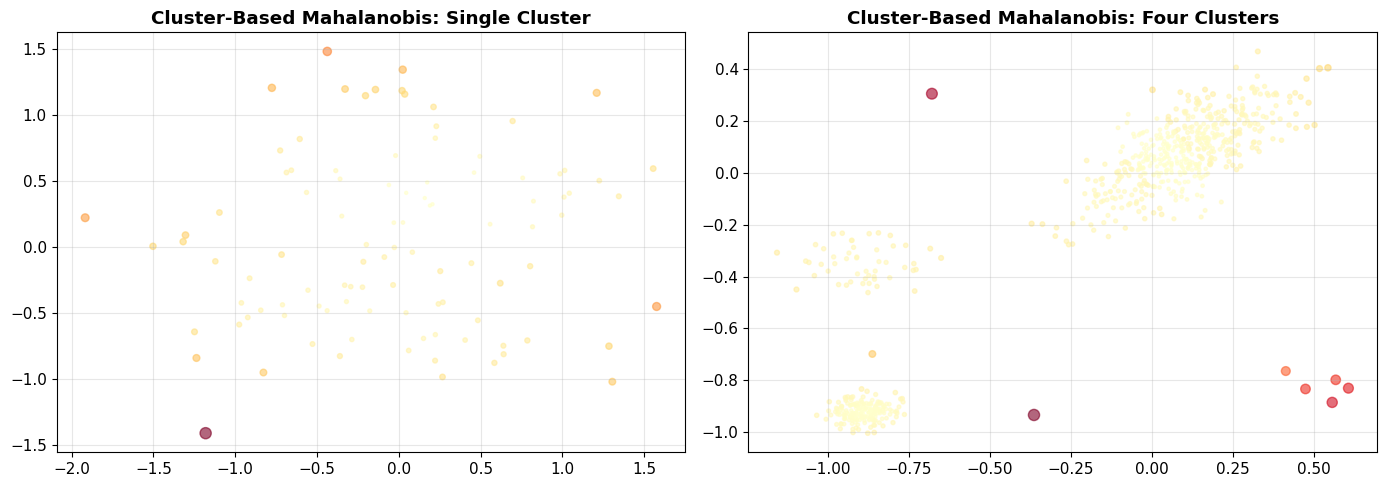

In [6]:
# Listing 7.8: Cluster-based Mahalanobis outlier detection
def cluster_based_outliers(df, sizes_weight=0.05):
    # Clean data first with IF
    clf_if = IsolationForest(random_state=0)
    clf_if.fit(df)
    pred = clf_if.decision_function(df)
    trimmed_df = df.loc[np.argsort(pred)[50:]]

    # Find best number of clusters
    best_score, best_n = np.inf, 2
    for n in range(2, 10):
        gmm = GaussianMixture(n_components=n, random_state=0)
        gmm.fit(trimmed_df)
        bic = gmm.bic(trimmed_df)
        if bic < best_score:
            best_score, best_n = bic, n

    gmm = GaussianMixture(n_components=best_n, random_state=0)
    gmm.fit(trimmed_df)
    X = df.copy()
    X['Cluster'] = gmm.predict(df)

    # Cluster sizes -> scores
    vc = X['Cluster'].value_counts()
    size_dict = dict(zip(vc.index, vc.values))
    size_scores = np.array([size_dict[x] for x in X['Cluster']])
    size_scores = MinMaxScaler().fit_transform(size_scores.reshape(-1,1)).flatten()
    size_scores = 1.0 - size_scores

    # Mahalanobis per cluster
    dfs_arr = []
    for ci in range(best_n):
        cdf = X[X['Cluster']==ci].copy()
        if len(cdf) < df.shape[1] + 2:
            cdf['Maha'] = 10.0  # too small for covariance
        else:
            cov = MinCovDet(random_state=0).fit(cdf[df.columns])
            cdf['Maha'] = cov.mahalanobis(cdf[df.columns])
            cdf['Maha'] = cdf['Maha'] / (cdf['Maha'].mean() + 1e-10)
        dfs_arr.append(cdf)

    maha = pd.concat(dfs_arr).sort_index()['Maha']
    maha = MinMaxScaler().fit_transform(maha.values.reshape(-1,1)).flatten()
    return sizes_weight * size_scores + maha

df_res1 = create_simple_testdata()
df_res1 = pd.DataFrame(RobustScaler().fit_transform(df_res1), columns=df_res1.columns)
df_res1['Score'] = cluster_based_outliers(df_res1)

df_res2 = create_four_clusters_test_data()
df_res2 = pd.DataFrame(RobustScaler().fit_transform(df_res2), columns=df_res2.columns)
df_res2['Score'] = cluster_based_outliers(df_res2)

plot_detector_results('Cluster-Based Mahalanobis')
print("Figure 7.8: Cluster-based Mahalanobis distance results.")

The cluster-based Mahalanobis method scores each point by (a) the size of its cluster (small clusters = higher scores) and (b) its Mahalanobis distance relative to the cluster average. The ratio normalization ensures scores are comparable across clusters with different densities and shapes.

The pipeline first cleans the data with Isolation Forest (removing the top $50$ most outlierish points) before clustering with GMM, which handles varied cluster shapes. This is a pattern worth adopting: **outlier detection to clean data for clustering, followed by cluster-based outlier detection** -- two complementary uses of outlier detection in sequence.

## 7.5 Entropy-Based Outlier Detection

**Entropy** measures uncertainty in data. The key insight for outlier detection: **removing an outlier decreases entropy more than removing an inlier**, because outliers contribute disproportionately to the uncertainty in the data.

$$H = -\sum_{i=1}^{k} p_i \log_2(p_i)$$

where $p_i$ is the probability of the $i$-th value. Entropy is maximized when all values are equally likely (high uncertainty) and minimized when one value dominates (low uncertainty).

The algorithm iteratively removes the row whose removal causes the largest entropy drop, labeling it as the most outlierish remaining record. This naturally handles categorical data.

Entropy detector flagged 8 outliers on subsampled data.
Entropy is a univariate test -- finds extreme values in individual features.


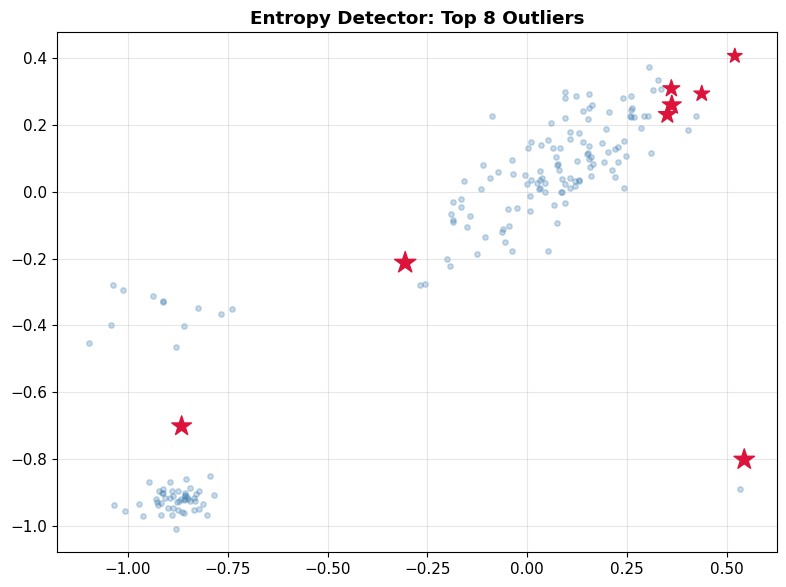

In [7]:
# Listing 7.11: Entropy-based outlier detection
class EntropyOutlierDetector:
    def __init__(self, num_outliers, num_bins=7):
        self.num_outliers = int(num_outliers)
        self.num_bins = num_bins

    def calculate_entropy(self, values):
        vc = values.value_counts(normalize=True)
        entropy = 0.0
        for v in vc.values:
            if v > 0:
                entropy += v * np.log2(v)
        return -entropy

    def fit_predict(self, df):
        df = df.copy()
        # Bin numeric columns
        binned_cols = []
        for col in df.columns:
            bcol = f'{col}_bin'
            df[bcol] = pd.cut(df[col], bins=self.num_bins)
            binned_cols.append(bcol)

        temp_df = df.copy()
        scores = np.zeros(len(df))

        for iteration in range(self.num_outliers):
            lowest_entropy = np.inf
            lowest_idx = -1
            for i in temp_df.index:
                total = sum(self.calculate_entropy(temp_df[c].drop(i)) for c in binned_cols)
                if total < lowest_entropy:
                    lowest_entropy = total
                    lowest_idx = i
            scores[lowest_idx] = self.num_outliers - iteration
            temp_df = temp_df.drop(index=lowest_idx)
        return scores

# Run on test data (small subset for speed)
np.random.seed(0)
df_ent = create_four_clusters_test_data().iloc[::4].reset_index(drop=True)  # subsample
df_ent_scaled = pd.DataFrame(RobustScaler().fit_transform(df_ent), columns=df_ent.columns)
entropy_scores = EntropyOutlierDetector(num_outliers=8, num_bins=8).fit_predict(df_ent_scaled)
df_ent_scaled['Score'] = entropy_scores

fig, ax = plt.subplots(figsize=(8, 6))
flagged = entropy_scores > 0
ax.scatter(df_ent_scaled.loc[~flagged,'A'], df_ent_scaled.loc[~flagged,'B'], alpha=0.3, s=15, c='steelblue')
ax.scatter(df_ent_scaled.loc[flagged,'A'], df_ent_scaled.loc[flagged,'B'],
           c='crimson', s=100+20*entropy_scores[flagged], marker='*', zorder=5)
ax.set_title('Entropy Detector: Top 8 Outliers', fontweight='bold')

plt.tight_layout()
print(f"Entropy detector flagged {flagged.sum()} outliers on subsampled data.")
print(f"Entropy is a univariate test -- finds extreme values in individual features.")

The Entropy detector identifies extreme values -- those whose removal most reduces the overall uncertainty in the data. As a **categorical-native** method (numeric features are binned), it handles mixed data naturally.

The iterative removal approach has an elegant property: each iteration finds the *next* most outlierish point given the current state of the data, avoiding masking effects. The first removed point may shield other outliers; once it is gone, those become more visible.

**Limitation:** Like HBOS and ECOD, Entropy treats features independently and cannot detect unusual combinations. To address this, the book suggests grouping columns into pairs, creating combined features that capture interactions.

## 7.6 Association Rules for Outlier Detection

**Association rule-based** outlier detection is one of the most **interpretable** methods available and handles **categorical data** well. It works in three steps:

1. **Mine frequent item sets** (FIS) -- combinations of values that appear together often
2. **Extract association rules** of the form $X \to Y$ (when $X$ is present, $Y$ tends to be present)
3. **Score each row** by its violations -- cases where the left-hand side $X$ is true but the right-hand side $Y$ is not

This is a **local** method: it evaluates each row only against the rules relevant to that row's values. An outlier is a row that violates many strong rules -- it has common values but in uncommon combinations.

In [8]:
# Simplified Association Rules demonstration
np.random.seed(42)
n = 1000

# Create categorical data with strong associations
dept = np.random.choice(['Sales', 'Engineering', 'Marketing'], n, p=[0.4, 0.35, 0.25])
region = np.random.choice(['East', 'West', 'Central'], n)
level = np.random.choice(['Junior', 'Mid', 'Senior'], n)

# Inject associations
for i in range(n):
    if dept[i] == 'Engineering':
        if np.random.random() < 0.7: level[i] = 'Senior'
        if np.random.random() < 0.6: region[i] = 'West'
    if dept[i] == 'Sales':
        if np.random.random() < 0.5: region[i] = 'East'
        if np.random.random() < 0.4: level[i] = 'Junior'

df_ar = pd.DataFrame({'dept': dept, 'level': level, 'region': region})

# Mine rules manually (simplified: check single-feature -> single-feature)
rules = []
for col_x in df_ar.columns:
    for val_x in df_ar[col_x].unique():
        for col_y in df_ar.columns:
            if col_x == col_y: continue
            for val_y in df_ar[col_y].unique():
                mask_x = df_ar[col_x] == val_x
                if mask_x.sum() < 50: continue  # min support
                mask_both = mask_x & (df_ar[col_y] == val_y)
                confidence = mask_both.sum() / mask_x.sum()
                support = mask_both.sum() / len(df_ar)
                if confidence >= 0.55:
                    rules.append({
                        'antecedent': f'{col_x}={val_x}',
                        'consequent': f'{col_y}={val_y}',
                        'confidence': confidence,
                        'support': support
                    })

rules_df = pd.DataFrame(rules).sort_values('confidence', ascending=False)
print(f"Association rules found (confidence >= 0.55): {len(rules_df)}")
print(f"\nTop 10 rules:")
print(rules_df.head(10).to_string(index=False))

# Score each row by rule violations
scores = np.zeros(len(df_ar))
for _, rule in rules_df.iterrows():
    col_x, val_x = rule['antecedent'].split('=')
    col_y, val_y = rule['consequent'].split('=')
    # Find rows where antecedent is true but consequent is false
    ant_true = df_ar[col_x] == val_x
    con_false = df_ar[col_y] != val_y
    violations = ant_true & con_false
    scores[violations] += rule['support']

df_ar['Rule_Score'] = scores

# Show top outliers
top_outliers = df_ar.nlargest(5, 'Rule_Score')
print(f"\nTop 5 outliers by rule violations:")
print(top_outliers.to_string())

Association rules found (confidence >= 0.55): 10

Top 10 rules:
      antecedent       consequent  confidence  support
dept=Engineering     level=Senior    0.800595    0.269
dept=Engineering      region=West    0.758929    0.255
     region=East       dept=Sales    0.683824    0.279
      dept=Sales      region=East    0.662708    0.279
    level=Junior       dept=Sales    0.658537    0.243
    level=Senior dept=Engineering    0.631455    0.269
     region=West dept=Engineering    0.623472    0.255
     region=West     level=Senior    0.581907    0.238
      dept=Sales     level=Junior    0.577197    0.243
    level=Senior      region=West    0.558685    0.238

Top 5 outliers by rule violations:
      dept   level region  Rule_Score
72   Sales  Senior   West       1.046
82   Sales  Senior   West       1.046
131  Sales  Senior   West       1.046
148  Sales  Senior   West       1.046
184  Sales  Senior   West       1.046


The association rules reveal the planted patterns: Engineering $\to$ Senior, Engineering $\to$ West, Sales $\to$ East. Rows that violate these strong associations (e.g., a Junior Engineer in the East) receive high outlier scores.

**Why this is so interpretable:** For each flagged row, we can list *exactly* which rules were violated and how strong those rules are. An analyst sees: "This record has dept=Engineering but level=Junior, violating the rule Engineering $\to$ Senior (confidence $0.70$, support $0.25$)." No other outlier detection method provides this level of explanation.

**Association rules vs. FPOF:** FPOF scores rows by the FISs they *contain* (fewer FISs = more outlierish). Association rules score rows by the rules they *violate* (more violations = more outlierish). These are complementary: FPOF finds rows with globally unusual value combinations, while association rules find rows with locally contradictory patterns. Using both together provides broader coverage.

## 7.7 Convex Hull (Convex Peeling)

**Convex Hull** outlier detection works by iteratively "peeling" layers off the data. At each iteration, points on the **convex hull** (the outermost boundary enclosing all points) are removed and scored. The process repeats on the remaining points, creating successively inner layers.

Points removed in the first layer are the most extreme outliers. Points removed in later layers are progressively more normal. This is intuitive and robust to masking (extreme outliers are removed first, revealing the next layer).

**Major limitation:** Convex Hull does not scale beyond $4$--$5$ features. In high dimensions, almost all points end up on the hull due to the curse of dimensionality.

Figure 7.12: Convex Hull peeling. Outermost points scored highest.


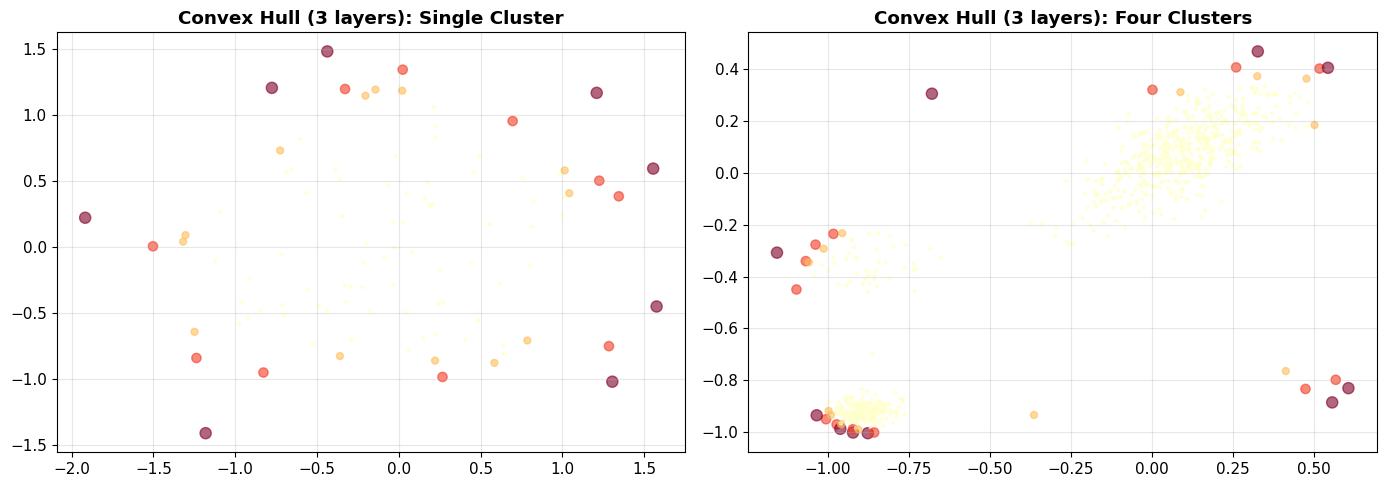

In [9]:
# Listing 7.15: Convex Hull outlier detection
class ConvexHullOutlierDetector:
    def __init__(self, num_iterations):
        self.num_iterations = num_iterations
    def fit_predict(self, df):
        scores = np.zeros(len(df))
        remaining = df.copy()
        remaining['orig_idx'] = remaining.index
        for it in range(self.num_iterations):
            if len(remaining) < 4: break
            try:
                hull = ConvexHull(remaining[df.columns].values)
            except:
                break
            hull_idxs = list(set(idx for simplex in hull.simplices for idx in simplex))
            for idx in hull_idxs:
                orig = remaining.iloc[idx]['orig_idx']
                scores[int(orig)] = self.num_iterations - it
            remaining = remaining.drop(remaining.index[hull_idxs]).reset_index(drop=True)
        return scores

df_res1 = create_simple_testdata()
df_res1 = pd.DataFrame(RobustScaler().fit_transform(df_res1), columns=df_res1.columns)
df_res1['Score'] = ConvexHullOutlierDetector(num_iterations=3).fit_predict(df_res1)

df_res2 = create_four_clusters_test_data()
df_res2 = pd.DataFrame(RobustScaler().fit_transform(df_res2), columns=df_res2.columns)
df_res2['Score'] = ConvexHullOutlierDetector(num_iterations=3).fit_predict(df_res2)

plot_detector_results('Convex Hull (3 layers)')
print("Figure 7.12: Convex Hull peeling. Outermost points scored highest.")

Convex Hull correctly identifies the outermost points in both datasets. With the single cluster, it creates concentric layers of decreasing outlierness. With four clusters, it catches the extreme global outliers and the outermost points of the data envelope.

Unlike density or distance-based methods, Convex Hull is purely geometric -- it uses the *shape* of the data boundary. This makes it a unique perspective complementary to other methods. However, it cannot detect internal outliers or local outliers within clusters, and its dimensionality limitation is severe.

## 7.8 Distance Metric Learning (DML)

**DML** uses a **Random Forest** to define similarity between records. Two records are "similar" if they frequently end in the **same leaf node** across the forest's trees. Outliers are records that rarely share leaf nodes with others -- they follow unique decision paths.

The approach trains a Random Forest to distinguish real data from synthetic (randomly generated) data. Records that the forest treats uniquely (ending in sparsely populated leaf nodes) are outliers.

Figure 7.13: DML results. Points in sparse leaf nodes score highest.


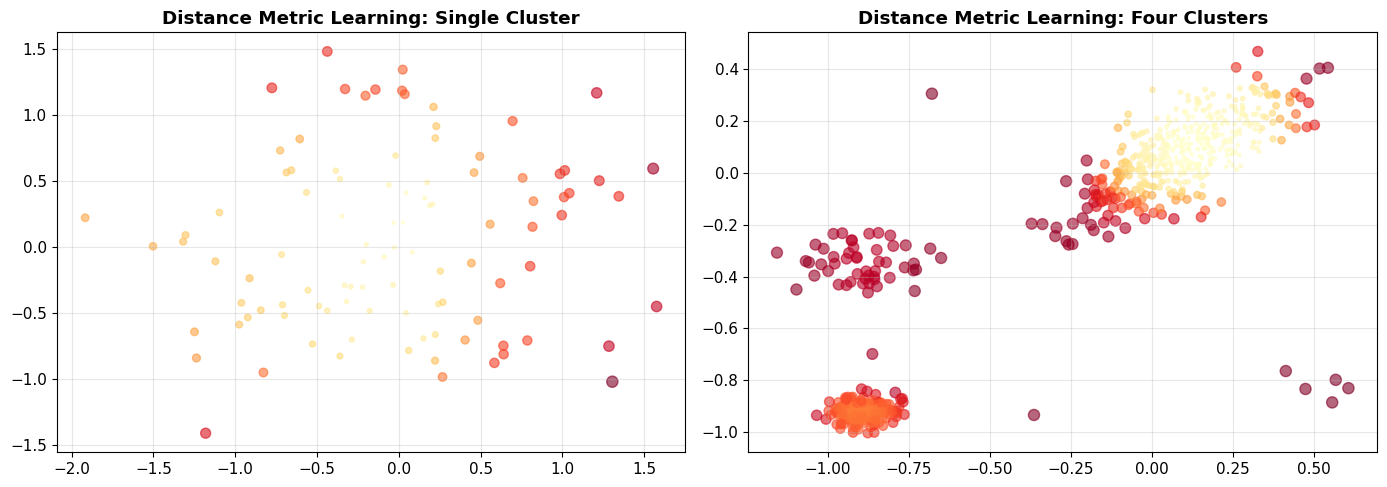

In [10]:
# Listing 7.16: DML outlier detection
class DMLOutlierDetection:
    def __init__(self):
        pass
    def fit_predict(self, df):
        real_df = df.copy(); real_df['Real'] = True
        synth_df = pd.DataFrame()
        for col in df.columns:
            synth_df[col] = np.random.normal(df[col].mean(), df[col].std(), len(df))
        synth_df['Real'] = False
        train = pd.concat([real_df, synth_df], ignore_index=True)
        clf = RandomForestClassifier(max_depth=5, random_state=0)
        clf.fit(train.drop(columns=['Real']), train['Real'])
        r = clf.apply(df)
        scores = np.zeros(len(df))
        for tree_idx in range(r.shape[1]):
            c = Counter(r[:, tree_idx])
            for rec_idx in range(len(df)):
                scores[rec_idx] += len(df) - c[r[rec_idx, tree_idx]]
        return scores

df_res1 = create_simple_testdata()
df_res1 = pd.DataFrame(RobustScaler().fit_transform(df_res1), columns=df_res1.columns)
df_res1['Score'] = DMLOutlierDetection().fit_predict(df_res1)

np.random.seed(0)
df_res2 = create_four_clusters_test_data()
df_res2 = pd.DataFrame(RobustScaler().fit_transform(df_res2), columns=df_res2.columns)
df_res2['Score'] = DMLOutlierDetection().fit_predict(df_res2)

plot_detector_results('Distance Metric Learning')
print("Figure 7.13: DML results. Points in sparse leaf nodes score highest.")

DML provides yet another perspective. The Random Forest captures **nonlinear relationships** between features that linear methods (Mahalanobis, PCA) might miss. Records that the forest routes to sparsely populated leaves are those that don't match the dominant patterns -- a natural definition of outlierness.

This approach can also be used as a **distance metric** for other detectors: instead of Euclidean distance between points, use "fraction of trees where two points share a leaf" as a similarity measure. This learned metric can be more meaningful than geometric distances in high-dimensional or mixed-type data.

## 7.9 NearestSample

**NearestSample** is a fast, sampling-based outlier detector. Each iteration, it selects a random sample of points and measures every point's distance to the nearest sample point. Inliers, being in dense regions, will usually have at least one sample point nearby. Outliers, being isolated, will typically be far from all sample points.

By repeating this many times and averaging, we get robust scores that are insensitive to any single random sample. The method has only two intuitive parameters: `n_iterations` and `n_samples`.

Figure 7.15: NearestSample results.


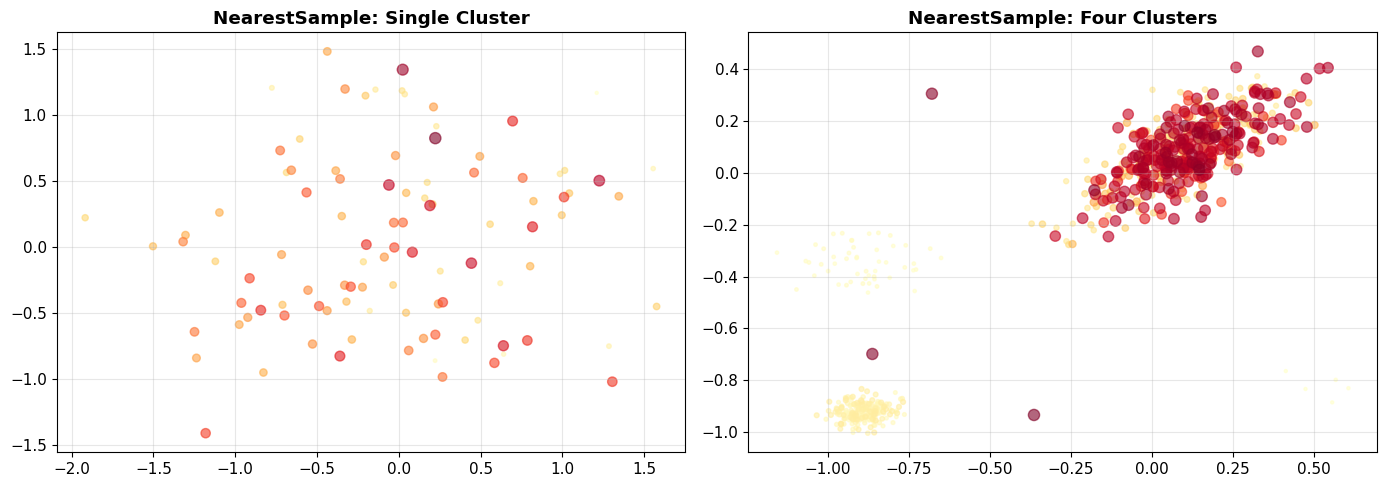

In [11]:
# Listing 7.17: NearestSample (simplified)
class NearestSampleDetector:
    def __init__(self, n_iterations=20, n_samples=50):
        self.n_iterations = n_iterations
        self.n_samples = n_samples
    def fit_predict(self, df):
        scores = np.zeros(len(df))
        tree = BallTree(df)
        for _ in range(self.n_iterations):
            sample_idxs = np.random.choice(len(df), min(self.n_samples, len(df)), replace=False)
            sample_pts = df.iloc[sample_idxs].values
            # For each point, find distance to nearest sample
            min_dists = np.full(len(df), np.inf)
            for sp in sample_pts:
                dist, _ = tree.query(sp.reshape(1, -1), k=len(df))
                min_dists = np.minimum(min_dists, dist[0])
            scores += min_dists
        return scores / self.n_iterations

df_res1 = create_simple_testdata()
df_res1 = pd.DataFrame(RobustScaler().fit_transform(df_res1), columns=df_res1.columns)
df_res1['Score'] = NearestSampleDetector(n_iterations=20, n_samples=5).fit_predict(df_res1)

np.random.seed(0)
df_res2 = create_four_clusters_test_data()
df_res2 = pd.DataFrame(RobustScaler().fit_transform(df_res2), columns=df_res2.columns)
df_res2['Score'] = NearestSampleDetector(n_iterations=30, n_samples=50).fit_predict(df_res2)

plot_detector_results('NearestSample')
print("Figure 7.15: NearestSample results.")

NearestSample provides smooth, robust scores because the averaging over many random samples eliminates dependence on any particular sample. Dense regions always have sample points nearby; sparse regions rarely do.

The method naturally captures **local behavior** because sample points are drawn in proportion to the data density. Dense clusters get many sample points, giving their members short minimum distances. Sparse regions get few, giving their members long distances. This happens without explicitly computing densities or defining neighborhoods.

## 7.10 Comparing All Chapter Algorithms

Let's run every algorithm from this chapter on the four-cluster test set and visualize the results side by side.

Comparison of all algorithms on the four-cluster test set.
Each algorithm emphasizes different aspects of outlierness.


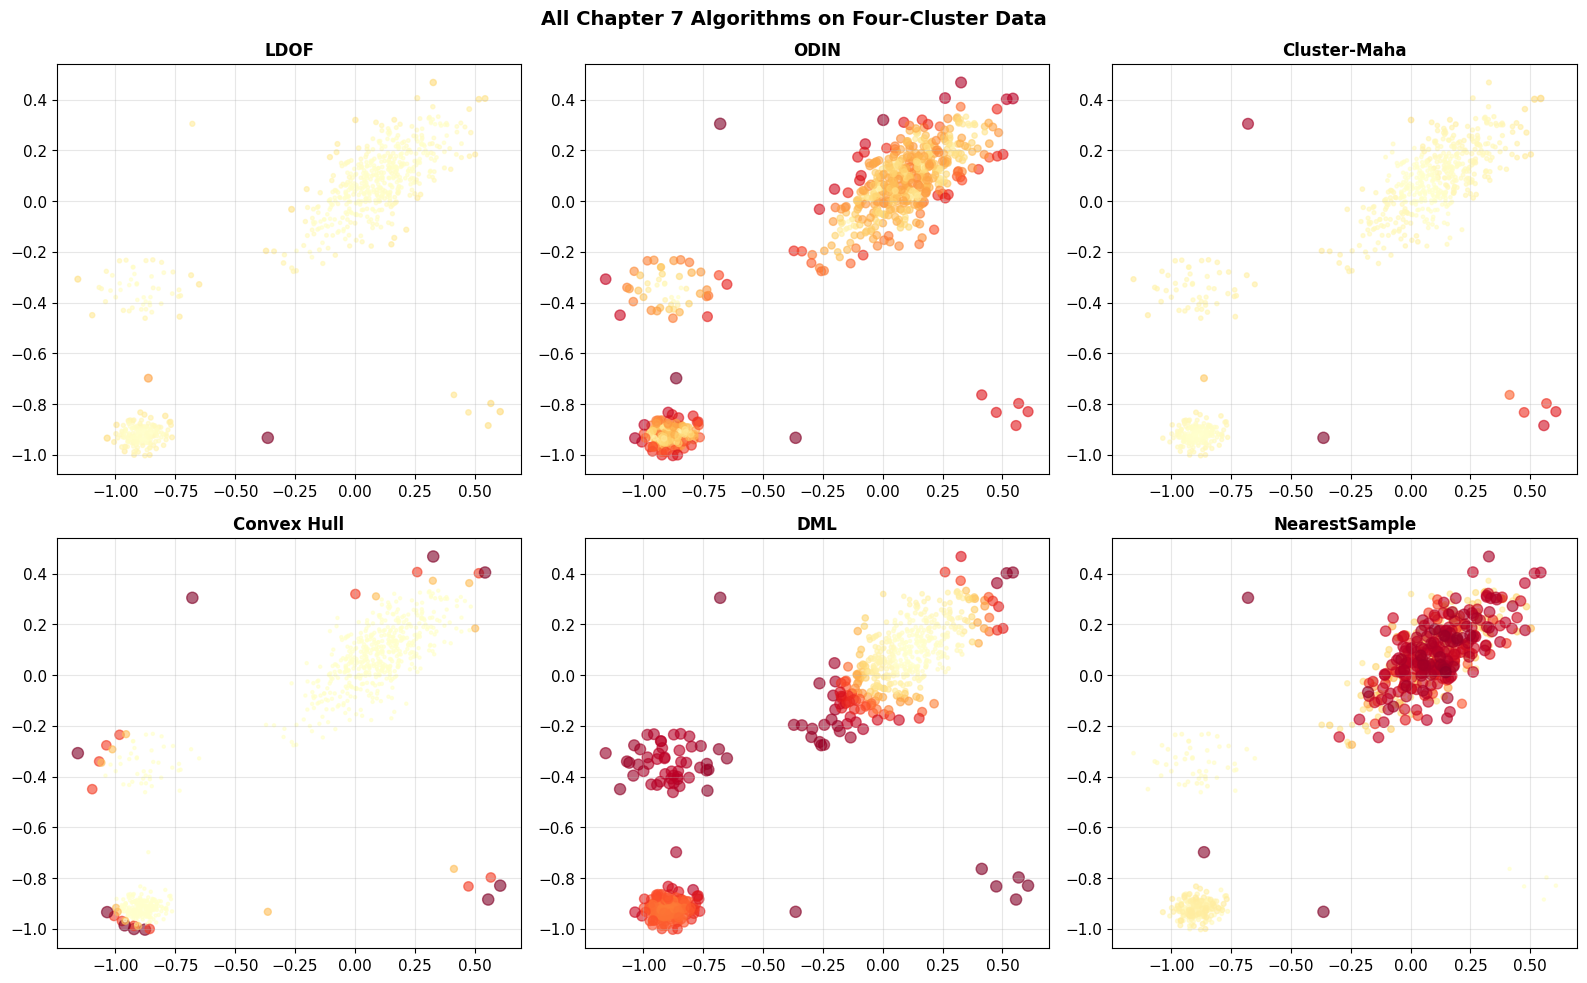

In [12]:
np.random.seed(0)
df_base = create_four_clusters_test_data()
df_s = pd.DataFrame(RobustScaler().fit_transform(df_base), columns=df_base.columns)

algorithms = {}

# LDOF
algorithms['LDOF'] = LDOFOutlierDetector().fit_predict(df_s, k=20)
# ODIN
algorithms['ODIN'] = ODINOutlierDetector().fit_predict(df_s, k=20)
# Cluster-Mahalanobis
algorithms['Cluster-Maha'] = cluster_based_outliers(df_s)
# Convex Hull
algorithms['Convex Hull'] = ConvexHullOutlierDetector(num_iterations=3).fit_predict(df_s)
# DML
algorithms['DML'] = DMLOutlierDetection().fit_predict(df_s)
# NearestSample
algorithms['NearestSample'] = NearestSampleDetector(n_iterations=30, n_samples=50).fit_predict(df_s)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (name, scores) in zip(axes.flat, algorithms.items()):
    sc = scores if isinstance(scores, np.ndarray) else np.array(scores)
    mn, mx = sc.min(), sc.max()
    sizes = 5 + 60 * (sc - mn) / (mx - mn + 1e-10)
    ax.scatter(df_s['A'], df_s['B'], c=sc, s=sizes, cmap='YlOrRd', alpha=0.6)
    ax.set_title(name, fontweight='bold', fontsize=12)

plt.suptitle('All Chapter 7 Algorithms on Four-Cluster Data', fontweight='bold', fontsize=14)
plt.tight_layout()

print("Comparison of all algorithms on the four-cluster test set.")
print("Each algorithm emphasizes different aspects of outlierness.")

The six-panel comparison reveals how each algorithm brings a distinct perspective:

**LDOF** compares each point to its neighbors' pairwise distances -- strong on local outliers. **ODIN** checks how many points consider each record a neighbor -- unique reverse-KNN perspective. **Cluster-Maha** evaluates within-cluster Mahalanobis distances -- best when clusters are well-defined. **Convex Hull** peels geometric layers -- catches only the most extreme points. **DML** uses Random Forest leaf co-occurrence -- captures nonlinear patterns. **NearestSample** uses sampling-based distance -- fast and robust.

No single algorithm dominates. This is precisely why the book advocates using **multiple detectors**: each catches outliers the others miss.

## 7.11 Chapter Summary

This chapter expanded the outlier detection toolkit beyond scikit-learn and PyOD:

**Additional libraries:** alibi-detect (Mahalanobis + deep learning), PyCaret (preprocessing + MLFlow integration), PyNomaly (LoOP)

**LOF variants:** LDOF (simpler, compares to neighbors' inter-distances), LoOP (probabilistic scores in $[0, 1]$), ODIN (reverse KNN / in-degree)

**Clustering-based:** Mahalanobis per cluster, KDE per cluster, kmodes for categorical data. Running global tests on each cluster separately is a powerful strategy.

**Categorical-native methods:** Entropy (information-theoretic), Association Rules (interpretable, local, rule-violation-based), kmodes clustering

**Geometric / model-based:** Convex Hull (peeling layers, limited to low dimensions), DML (Random Forest leaf co-occurrence), NearestSample (fast sampling-based distances)

**Key takeaways:**
- Implementing outlier detectors from scratch is often straightforward -- many algorithms are $20$--$50$ lines of core logic
- Categorical data requires specialized methods (Entropy, Association Rules, FPOF, kmodes)
- Association Rules is the most **interpretable** outlier detection method -- each score comes with an explanation
- Running global tests per cluster is underused but powerful
- Every algorithm provides a different perspective; using many detectors together is always stronger than using one

In the next chapter, we begin exploring **preprocessing and tuning** strategies for outlier detection in depth.

## Appendix: OpenML Examples (Run on Google Colab)

In [13]:
# Run on Google Colab -- Listings 7.12-7.14: Association Rules on SpeedDating
# pip install mlxtend
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd
from sklearn.datasets import fetch_openml

data = fetch_openml('SpeedDating', version=1, parser='auto')
data_df = pd.DataFrame(data.data, columns=data.feature_names)
data_df = data_df[['d_pref_o_attractive', 'd_pref_o_sincere',
                    'd_pref_o_intelligence', 'd_pref_o_funny',
                    'd_pref_o_ambitious', 'd_pref_o_shared_interests']]
data_df = pd.get_dummies(data_df)

frequent_itemsets = apriori(data_df, min_support=0.3, use_colnames=True)
assoc_rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)
print(assoc_rules[['antecedents', 'consequents', 'support', 'confidence']].head(10))

# Score by violations
data_df['Score'] = 0
for idx in assoc_rules.index:
    ant = list(assoc_rules.loc[idx, 'antecedents'])
    con = list(assoc_rules.loc[idx, 'consequents'])
    support = assoc_rules.loc[idx, 'support']
    cond_ant = data_df[ant[0]]
    for a in ant[1:]: cond_ant = cond_ant & data_df[a]
    cond_con = data_df[con[0]]
    for c in con[1:]: cond_con = cond_con & data_df[c]
    violations = list(set(data_df[cond_ant].index) - set(data_df[cond_ant & cond_con].index))
    data_df.loc[violations, 'Score'] += support

print(f"\nTop outlier: row {data_df['Score'].idxmax()}")

                                         antecedents  \
0                     (d_pref_o_attractive_[21-100])   
1                     (d_pref_o_attractive_[21-100])   
2                          (d_pref_o_sincere_[0-15])   
3                           (d_pref_o_funny_[16-20])   
4                            (d_pref_o_funny_[0-15])   
5                        (d_pref_o_ambitious_[0-15])   
6                 (d_pref_o_shared_interests_[0-15])   
7  (d_pref_o_attractive_[21-100], d_pref_o_ambiti...   
8  (d_pref_o_attractive_[21-100], d_pref_o_shared...   
9                     (d_pref_o_attractive_[21-100])   

                                         consequents   support  confidence  
0                        (d_pref_o_ambitious_[0-15])  0.347577    0.967442  
1                 (d_pref_o_shared_interests_[0-15])  0.320840    0.893023  
2                        (d_pref_o_ambitious_[0-15])  0.320243    0.875367  
3                    (d_pref_o_intelligence_[16-20])  0.332657    0.720155 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
